# Objective 2 — Model vs Observed Storm Validation

In this section we assess how well the NZ wave hindcast model reproduces observed storm conditions measured by the ECAN wave buoy in Pegasus Bay.

We compare monthly storm statistics derived from:
- **Observed buoy data (ECAN)**
- **Model hindcast data (NZ Open Modelling Consortium)**

We focus on storm-relevant wave properties:
- Significant wave height (Hs)
- Storm duration (storm hours)
- Mean wave direction

The goal is to quantify:
- Bias (systematic over- or under-estimation)
- Random error (RMSE)
- Correlation between model and observations

This allows us to evaluate whether the hindcast model is reliable enough to be used for historical and future erosion risk analysis.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set project paths
PROJECT_DIR = Path(r"C:\Users\anura\Downloads\DATA601-PROJECT")
TABLE_DIR = PROJECT_DIR / "results" / "tables"
FIG_DIR = PROJECT_DIR / "results" / "figures"

# Load the merged monthly storm–shoreline dataset
df = pd.read_csv(
    TABLE_DIR / "storm_shoreline_merged_monthly.csv",
    parse_dates=["month"]
)

print("Rows:", len(df))
display(df.head())


Rows: 314


,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month
0,1999-07-01,NaN,10.0,3.22,2.694000,150.844000,20.0,6.1611,4.835027,148.519700,False
1,1999-08-01,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.4776,4.375580,195.086000,False
2,1999-09-01,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.5849,4.377566,197.312429,False
3,1999-10-01,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,1999-11-01,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## We only compare months where both the ECAN buoy and the NZ hindcast detected storms.This avoids contaminating the validation with calm months.


In [4]:
# Keep only months where both buoy and model report storms
valid = df[
    df["ecan_storm_hours"].notna() &
    df["model_storm_hours"].notna()
].copy()

print("Months with storms in both datasets:", len(valid))
display(valid[["month","ecan_storm_hours","model_storm_hours"]].head())


Months with storms in both datasets: 177


,month,ecan_storm_hours,model_storm_hours
0,1999-07-01,10.0,20.0
1,1999-08-01,7.0,2.0
2,1999-09-01,2.0,7.0
13,2000-08-01,9.0,5.0
14,2000-09-01,7.0,5.0


## To evaluate model performance we use:

- Bias: mean(model − observed)
- RMSE: typical magnitude of errors
- Correlation: how well the model tracks observed variability


In [5]:
def skill_metrics(obs, mod):
    diff = mod - obs
    bias = diff.mean()
    rmse = np.sqrt(np.mean(diff**2))
    corr = np.corrcoef(obs, mod)[0,1]
    return bias, rmse, corr


## We now compute model skill for storm‐relevant wave variables.


In [6]:
metrics = {}

metrics["Hs"] = skill_metrics(valid["ecan_mean_Hs"], valid["model_mean_Hs"])
metrics["Storm hours"] = skill_metrics(valid["ecan_storm_hours"], valid["model_storm_hours"])
metrics["Direction"] = skill_metrics(valid["ecan_mean_dir"], valid["model_mean_dir"])

summary = pd.DataFrame(
    metrics,
    index=["Bias", "RMSE", "Correlation"]
).T

display(summary)

# Save for report
summary.to_csv(TABLE_DIR / "table_model_vs_buoy_validation.csv")
print("Saved table_model_vs_buoy_validation.csv")


,Bias,RMSE,Correlation
Hs,2.025641,2.075863,-0.015965
Storm hours,-13.152542,20.665755,0.135908
Direction,28.833071,46.680937,0.338918


Saved table_model_vs_buoy_validation.csv


## Scatter plots show how closely the hindcast reproduces observed storm conditions.
The dashed line represents perfect agreement.


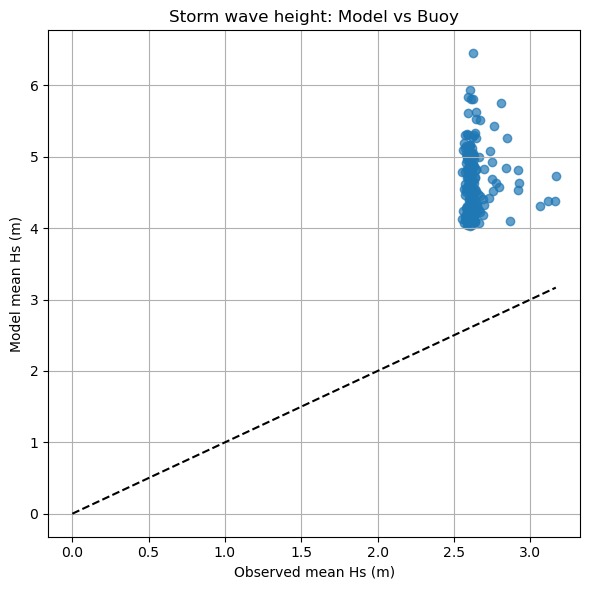

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(valid["ecan_mean_Hs"], valid["model_mean_Hs"], alpha=0.7)
plt.plot([0, valid["ecan_mean_Hs"].max()], [0, valid["ecan_mean_Hs"].max()], "k--")
plt.xlabel("Observed mean Hs (m)")
plt.ylabel("Model mean Hs (m)")
plt.title("Storm wave height: Model vs Buoy")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_model_vs_buoy_Hs.png", dpi=200)
plt.show()


## We also compare storm duration measured by the buoy and hindcast.


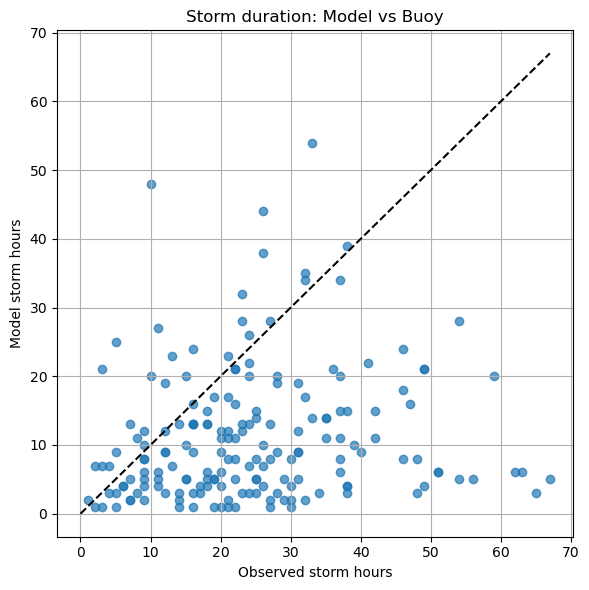

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(valid["ecan_storm_hours"], valid["model_storm_hours"], alpha=0.7)
plt.plot([0, valid["ecan_storm_hours"].max()], [0, valid["ecan_storm_hours"].max()], "k--")
plt.xlabel("Observed storm hours")
plt.ylabel("Model storm hours")
plt.title("Storm duration: Model vs Buoy")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_model_vs_buoy_duration.png", dpi=200)
plt.show()


## Finally we compare mean wave direction between buoy and model.


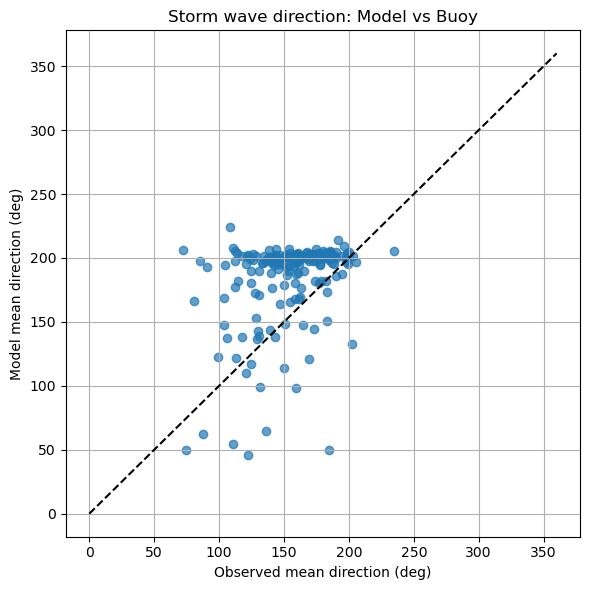

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(valid["ecan_mean_dir"], valid["model_mean_dir"], alpha=0.7)
plt.plot([0,360],[0,360],"k--")
plt.xlabel("Observed mean direction (deg)")
plt.ylabel("Model mean direction (deg)")
plt.title("Storm wave direction: Model vs Buoy")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_model_vs_buoy_direction.png", dpi=200)
plt.show()
